# Imports

In [ ]:
from random import random
from data_loader import load_conll2003
from preprocessing import build_vocab, tokenize
from model import SkipGramNS
from trainer import train_skipgram
from utils import word_analogy, save_embeddings, most_similar
from dataset import get_negative_samples, create_skipgram_pairs
from hmm import HMM_NER
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)
print("All modules imported successfully.")

All modules imported successfully.


# Load dataset

In [9]:
print("Loading CoNLL2003 dataset...")

train_text,train_sentences, train_tags, test_sentences, test_true_tags = load_conll2003()

# Use train split for Word2Vec training
sentences = train_text

print("Dataset loaded successfully.")
print("Train sentences:", len(train_text))
print("Test sentences:", len(test_sentences))

print("\nExample train sentence:")
print(sentences[0])

Loading CoNLL2003 dataset...
Dataset loaded successfully.
Train sentences: 14041
Test sentences: 3453

Example train sentence:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']


# Build vocab

In [11]:
print("Building vocabulary...")

# Tokenize training data only
tokenized = tokenize(train_text)

# Build vocabulary
vocab, idx_to_word = build_vocab(tokenized)
V = len(vocab)

print("Vocabulary size:", V)

print("\nExample word to index mapping:")
for word in list(vocab.keys())[:10]:
    print(f"{word}: {vocab[word]}")

Building vocabulary...
Vocabulary size: 11982

Example word to index mapping:
EU: 0
German: 1
call: 2
to: 3
boycott: 4
British: 5
lamb: 6
.: 7
Peter: 8
Blackburn: 9


# Create dataset

In [12]:
print("Creating Skip-Gram dataset...")

window_size = 2
pairs = create_skipgram_pairs(tokenized, vocab, window_size)
print("Number of training pairs:", len(pairs))

for i in range(10):
    target, context = pairs[i]
    print(
        idx_to_word[target],
        "->",
        idx_to_word[context]
    )

Creating Skip-Gram dataset...
Number of training pairs: 684802
EU -> German
EU -> call
German -> EU
German -> call
German -> to
call -> EU
call -> German
call -> to
call -> boycott
to -> German


# Create model

In [13]:
embedding_dim = 100

print("Initializing Word2Vec SGNS model...")

model = SkipGramNS(vocab_size=V, embedding_dim=embedding_dim)

print("Model initialized successfully.")
print("Shape of target embeddings:", model.W_out.shape)
print("Shape of context embeddings:", model.W_in.shape)

Initializing Word2Vec SGNS model...
Model initialized successfully.
Shape of target embeddings: (11982, 100)
Shape of context embeddings: (11982, 100)


# Train model

In [6]:
# Train
epochs = 15
loss_history = train_skipgram(
    pairs=pairs,
    vocab=vocab,
    model=model,
    window_size=4,
    neg_samples=5,
    lr=0.05,
    epochs=epochs
)
print("Training finished.")

KeyboardInterrupt: 

# Plot 

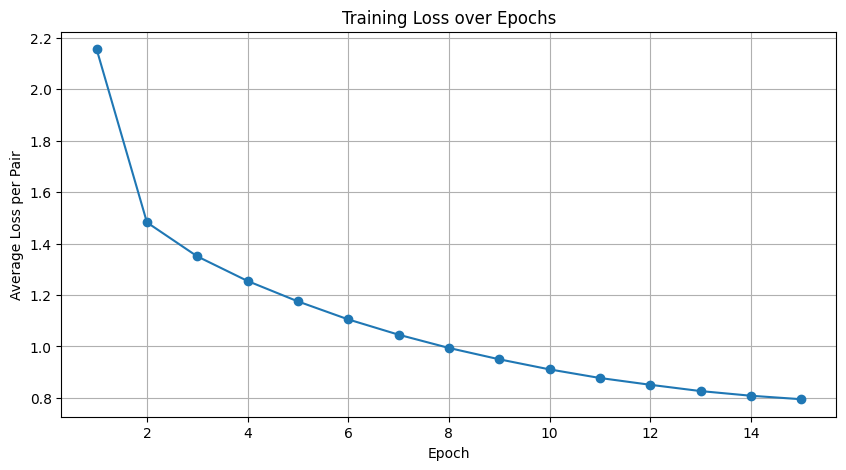

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(range(1, epochs+1), loss_history, marker='o')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average Loss per Pair")  # changed from Total Loss
plt.grid(True)
plt.show()

# Similarity Test

In [14]:
W_in_norm = model.W_in / (np.linalg.norm(model.W_in, axis=1, keepdims=True) + 1e-9)

# Most similar to 'match'
print("\nMost similar words to 'match':")
results = most_similar("match", vocab, idx_to_word, W_in_norm, topk=5)
for i, (word, score) in enumerate(results, 1):
    print(f"{i}. {word} -> {score:.4f}")

# Most similar to 'tournament'
print("\nMost similar words to 'tournament':")
results = most_similar("tournament", vocab, idx_to_word, W_in_norm, topk=5)
for i, (word, score) in enumerate(results, 1):
    print(f"{i}. {word} -> {score:.4f}")

# Most similar to 'percent'
print("\nMost similar words to 'percent':")
results = most_similar("percent", vocab, idx_to_word, W_in_norm, topk=5)
for i, (word, score) in enumerate(results, 1):
    print(f"{i}. {word} -> {score:.4f}")

# Most similar to 'year'
print("\nMost similar words to 'year':")
results = most_similar("year", vocab, idx_to_word, W_in_norm, topk=5)
for i, (word, score) in enumerate(results, 1):
    print(f"{i}. {word} -> {score:.4f}")


Most similar words to 'match':
1. SPREAD -> 0.3812
2. Interior -> 0.3398
3. Francisco -> 0.3304
4. 1950s -> 0.3267
5. stormed -> 0.3179

Most similar words to 'tournament':
1. organisers -> 0.4202
2. MIDEAST -> 0.3958
3. aircraft -> 0.3478
4. 12-8 -> 0.3467
5. producer -> 0.3344

Most similar words to 'percent':
1. Khalq -> 0.3908
2. BUDAPEST -> 0.3757
3. latter -> 0.3752
4. ought -> 0.3668
5. favorable -> 0.3519

Most similar words to 'year':
1. anything -> 0.3890
2. racing -> 0.3721
3. sleep -> 0.3556
4. Jean-Philippe -> 0.3480
5. Wally -> 0.3198


# Save Embeddings

In [15]:
embeddings_file = "embeddings.txt"
save_embeddings(model.W_in, idx_to_word, embeddings_file)
print(f"Embeddings saved to {embeddings_file}")

Embeddings saved to embeddings.txt


# Word Analogy

In [ ]:
# Analogy: badminton : badminton :: football : ?
result = word_analogy("badminton", "badminton", "football", W_in_norm, vocab, idx_to_word, topk=5)

print("Analogy: 'badminton' is to 'badminton' as 'football' is to ?")
for i, (word, score) in enumerate(result, 1):
    print(f"{i}. {word} -> {score:.4f}")

# Analogy: brussels : belgium :: berlin : ?
result = word_analogy("Brussels", "Belgium", "Berlin", W_in_norm, vocab, idx_to_word, topk=5)
print("\nAnalogy: 'Brussels' is to 'Belgium' as 'Berlin' is to ?")
for i, (word, score) in enumerate(result, 1):
    print(f"{i}. {word} -> {score:.4f}")

Analogy: 'badminton' is to 'badminton' as 'football' is to ?
1. representative -> 0.3732
2. Howard -> 0.3362
3. waters -> 0.3348
4. gathered -> 0.3344
5. place -> 0.3304

Analogy: 'Brussels' is to 'Belgium' as 'Berlin' is to ?
1. provide -> 0.3539
2. 4-53 -> 0.3466
3. 525 -> 0.3252
4. homered -> 0.3240
5. Briton -> 0.3223


# Hidden Markov

In [16]:
# Initialize and train
hmm = HMM_NER()
hmm.train(train_sentences, train_tags)

# Decode test set
predicted_tags = []
for sentence in test_sentences:
    pred = hmm.viterbi(sentence)
    predicted_tags.append(pred)

# Flatten lists for evaluation
flat_true = [tag for seq in test_true_tags for tag in seq]
flat_pred = [tag for seq in predicted_tags for tag in seq]

# Evaluate the performance using accuracy, precision, recall, and F1-score
print("Accuracy:", accuracy_score(flat_true, flat_pred))
print(classification_report(flat_true, flat_pred))

Accuracy: 0.8253041886508022
              precision    recall  f1-score   support

           0       0.83      1.00      0.90     38323
           1       0.00      0.00      0.00      1617
           2       0.00      0.00      0.00      1156
           3       0.00      0.00      0.00      1661
           4       0.00      0.00      0.00       835
           5       0.00      0.00      0.00      1668
           6       0.00      0.00      0.00       257
           7       0.00      0.00      0.00       702
           8       0.00      0.00      0.00       216

    accuracy                           0.83     46435
   macro avg       0.09      0.11      0.10     46435
weighted avg       0.68      0.83      0.75     46435



c:\Users\alyad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alyad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alyad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave